In [37]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 确保本地包可 import（在 repo 根目录 or 子目录里都能跑）
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "alpha_lab").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from alpha_lab.config import get_paths, ensure_dir
paths = get_paths()
ensure_dir(paths.data_raw_dir)


PosixPath('/Users/shusheng/PythonProjects/alpha_lab/data/raw')

In [38]:
# 导入模块（核心代码已修复，无需 monkey patch）
import numpy as np
import pandas as pd

import alpha_lab.portfolio.rebalance as reb
import alpha_lab.backtest.engine as eng
import alpha_lab.metrics.drawdown as dd
from alpha_lab.utils.dates import parse_date, generate_rebalance_dates

# 注意：之前这里有大量 monkey patch 代码来修复以下问题：
# 1. _generate_rebalance_schedule_fixed - 现已在 rebalance.py 中修复
# 2. _simulate_portfolio_fixed - 现已在 engine.py 中修复（日期比较和边界条件）
# 3. _compute_drawdown_series_fixed - 现已在 drawdown.py 中修复
# 4. _compute_drawdown_metrics_fixed - 现已在 drawdown.py 中修复
# 
# 这些修复已合并到核心代码中，此 cell 现在只需要导入模块即可

In [39]:
USE_SYNTHETIC = False# 如果你有真实 CSV，改成 False
csv_path = paths.data_raw_dir / "close.csv"

if USE_SYNTHETIC or not csv_path.exists():
    rng = np.random.default_rng(7)
    dates = pd.date_range("2022-01-03", periods=260, freq="B")
    tickers = ["AAA", "BBB", "CCC", "DDD", "EEE"]

    prices = pd.DataFrame(
        100 * np.exp(np.cumsum(rng.normal(0, 0.01, (len(dates), len(tickers))), axis=0)),
        index=dates,
        columns=tickers,
    )
    prices.index.name = "date"
    prices.reset_index().to_csv(csv_path, index=False)

    print("wrote", csv_path)
else:
    print("use existing", csv_path)


use existing /Users/shusheng/PythonProjects/alpha_lab/data/raw/close.csv


In [40]:
# 重新加载模块以确保使用最新修复的代码
import importlib
import sys

# 重新加载核心模块
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('alpha_lab'):
        try:
            importlib.reload(sys.modules[mod_name])
        except:
            pass

from alpha_lab.data.loader import load_prices
from alpha_lab.factors.momentum import momentum
from alpha_lab.factors.transform import zscore
from alpha_lab.portfolio.rebalance import generate_rebalance_schedule
from alpha_lab.portfolio.weighting import top_k_long_only

# 从真实 CSV 文件读取 tickers 和日期范围
prices_df = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
tickers = prices_df.columns.tolist()
dates = prices_df.index

start_ts = dates.min()
end_ts = dates.max()

prices_loaded = load_prices(
    universe=tickers,
    start_date=start_ts,
    end_date=end_ts,
    field="close",
    source="csv",
    align_dates=True,
)

factor = momentum(prices_loaded, lookback=10, lag=1, method="log")
factor = zscore(factor, axis=1)

rebalance_dates = generate_rebalance_schedule(
    trading_calendar=prices_loaded.index,
    start_date=start_ts,
    end_date=end_ts,
    freq="W",
)

# 使用 reindex 而不是 loc 来处理日期对齐问题
# rebalance_dates 是交易日历中每月的最后一个交易日
# 需要确保这些日期在 factor 索引中存在
factor_reb = factor.reindex(rebalance_dates).dropna(how='all')
weights = top_k_long_only(factor_reb, k_pct=0.2, equal_weight=True)

print("prices", prices_loaded.shape, "factor", factor.shape, "weights", weights.shape)
print("rebalance_dates sample:", rebalance_dates[:3].tolist())

2026-01-02 10:05:44 | INFO     | alpha_lab.data.loader | Loading close prices: 10 tickers, 2022-01-03 to 2022-12-30
2026-01-02 10:05:44 | INFO     | alpha_lab.data.loader | Loaded: 251 days x 10 assets
2026-01-02 10:05:44 | INFO     | alpha_lab.portfolio.rebalance | Generated 52 rebalance dates (freq=W)
prices (251, 10) factor (251, 10) weights (52, 10)
rebalance_dates sample: [Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-14 00:00:00'), Timestamp('2022-01-21 00:00:00')]


In [41]:
from alpha_lab.backtest.engine import run_backtest
from alpha_lab.config.backtest import BacktestConfig
from alpha_lab.metrics.summary import generate_backtest_summary

cfg = BacktestConfig(
    start_date=start_ts.date().isoformat(),
    end_date=end_ts.date().isoformat(),
    rebalance_freq="M",
    initial_cash=1_000_000.0,
    commission_bps=0.0,
    slippage_bps=0.0,
    price_field="close",
)

result = run_backtest(weights=weights, prices=prices_loaded, config=cfg, verbose=True)
metrics = generate_backtest_summary(result, as_dataframe=False)

metrics


2026-01-02 10:05:44 | INFO     | alpha_lab.backtest.engine | Running backtest: 2022-01-03 to 2022-12-30, freq=M, initial_cash=1,000,000
2026-01-02 10:05:44 | INFO     | alpha_lab.portfolio.rebalance | Generated 12 rebalance dates (freq=M)

[2022-04-29] REBALANCE
  Portfolio Value: $1,000,000
  Trade Value:     $1,000,000
  Turnover:        100.0%
  Cost:            $0.00 (comm=0.00, slip=0.00)
  Top Holdings:    V:50.0%, JNJ:50.0%

[2022-07-29] REBALANCE
  Portfolio Value: $985,207
  Trade Value:     $1,970,414
  Turnover:        200.0%
  Cost:            $0.00 (comm=0.00, slip=0.00)
  Top Holdings:    TSLA:50.0%, XOM:50.0%

[2022-09-30] REBALANCE
  Portfolio Value: $887,746
  Trade Value:     $1,775,492
  Turnover:        200.0%
  Cost:            $0.00 (comm=0.00, slip=0.00)
  Top Holdings:    JNJ:50.0%, WMT:50.0%

[2022-12-30] REBALANCE
  Portfolio Value: $970,160
  Trade Value:     $1,940,320
  Turnover:        200.0%
  Cost:            $0.00 (comm=0.00, slip=0.00)
  Top Holdings: 

{'total_return': np.float64(-0.029840010611734136),
 'cagr': np.float64(-0.03007510453720308),
 'annualized_vol': np.float64(0.1820250416581603),
 'sharpe_ratio': np.float64(-0.0762007802836332),
 'win_rate': np.float64(0.35856573705179284),
 'best_day': np.float64(0.03431015135029858),
 'worst_day': np.float64(-0.049530434217219255),
 'n_periods': 251,
 'max_drawdown': np.float64(0.12955886734312644),
 'avg_drawdown': np.float64(0.0443155208895816),
 'current_drawdown': np.float64(0.04292952687781971),
 'max_drawdown_duration': 71}

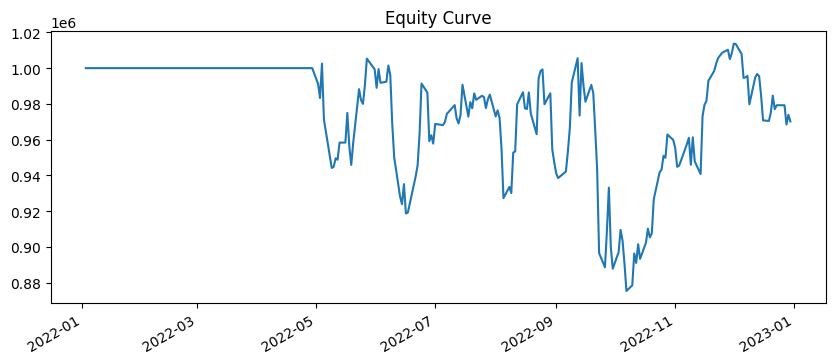

In [42]:
import matplotlib.pyplot as plt

result.equity_curve.plot(figsize=(10, 4), title="Equity Curve")
plt.show()


In [43]:
result.trades

,date,asset,shares,price,value
0,2022-04-29,V,2413.837607,207.139038,500000.000000
1,2022-04-29,JNJ,3095.186818,161.541138,500000.000000
2,2022-07-29,TSLA,1657.760134,297.149994,492603.413699
3,2022-07-29,V,-2413.837607,206.541428,-498557.465364
4,2022-07-29,JNJ,-3095.186818,157.227783,-486649.362033
5,2022-07-29,XOM,5734.848519,85.896500,492603.413699
6,2022-09-30,TSLA,-1657.760134,265.250000,-439720.875543
7,2022-09-30,JNJ,2995.854939,148.162415,443873.101409
8,2022-09-30,WMT,10689.570650,41.523941,443873.101409
9,2022-09-30,XOM,-5734.848519,78.123306,-448025.327275
